In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Gradient descent code (Multiple Linear regression)

In [2]:

class GDRegressor:
    
    def __init__(self, learning_rate, epochs):
        self.lr = learning_rate
        self.epochs = epochs
        self.w = None
        self.b = 0
        
    def fit(self, X, y):
        n, f = X.shape
        self.w = np.zeros(f)
        
        for i in range(self.epochs):
            
            y_pred = np.dot(X, self.w) + self.b
            
            error = y - y_pred
            
            dw = (-2/n) * np.dot(X.T, error)
            db = (-2/n) * np.sum(error)
            
            self.w -= self.lr * dw
            self.b -= self.lr * db
            
        print(f"After {self.epochs} epochs:")
        print("Weights:", self.w)
        print("Bias:", self.b)
        
    def predict(self, X):
        return np.dot(X, self.w) + self.b


### Dataset

In [3]:
d = pd.read_csv("pima_indians_diabetes.csv")

In [4]:
X = d.iloc[:, :-1].values   
y = d.iloc[:, -1].values   

### Splitting the train/test dataset

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

### Standardize the dataset

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Mannual logistic regression pipeline

In [7]:
class LogisticRegressionGD:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.w = None
        self.b = 0
        
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
        
    def fit(self, X, y):
        n, f = X.shape
        self.w = np.zeros(f)
        
        for i in range(self.epochs):
            linear_pred = np.dot(X, self.w) + self.b
            y_pred = self.sigmoid(linear_pred)
            
            error = y_pred - y
            dw = (1/n) * np.dot(X.T, error)
            db = (1/n) * np.sum(error)
            
            self.w -= self.lr * dw
            self.b -= self.lr * db
            
        print(f"Training Complete! (After {self.epochs} epochs)")
        print("Weights:", self.w)
        print("Bias:", self.b)
        
    def predict(self, X):
        linear_pred = np.dot(X, self.w) + self.b
        y_pred = self.sigmoid(linear_pred)
        return np.array([1 if p >= 0.5 else 0 for p in y_pred])

### Fitting the model

In [8]:
model = LogisticRegressionGD(learning_rate=0.1, epochs=1000)
model.fit(X_train_scaled, y_train)

Training Complete! (After 1000 epochs)
Weights: [ 0.41531229  1.22544904 -0.29891764 -0.02194178 -0.13496415  0.64840136
  0.26070697  0.11954538]
Bias: -0.8728389104003744


### Prediction

In [9]:
y_pred_custom = model.predict(X_test_scaled)

### Model accuracy

In [10]:

print(f"Accuracy: {accuracy_score(y_test, y_pred_custom) * 100:.2f}%")


Accuracy: 74.68%


### confusion matrix

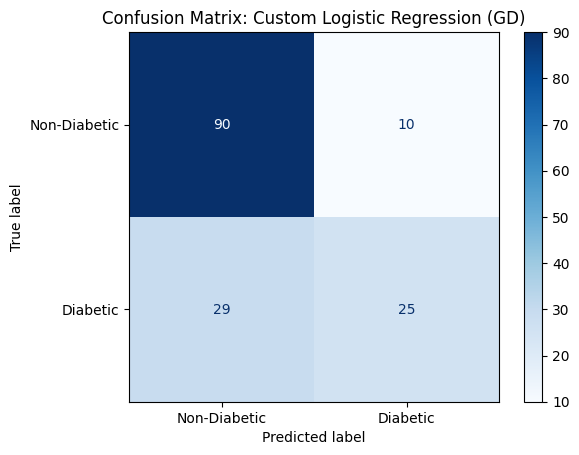

In [11]:
cm = confusion_matrix(y_test, y_pred_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetic', 'Diabetic'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: Custom Logistic Regression (GD)')
plt.show()